# Clustering com scikit-learn

Neste notebook, exploraremos técnicas de clustering usando **scikit-learn**. Abordaremos:

1. **K-Means Clustering** com visualização de clusters em 2D
2. **Agrupamento hierárquico** usando AgglomerativeClustering
3. **Avaliação de clusters** com silhouette_score

# Importando as bibliotecas necessárias

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo dos gráficos

In [2]:
sns.set(style="darkgrid")

# Gerando um conjunto de dados sintético para clustering

In [3]:
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.7, random_state=42)

# Visualizando os dados iniciais

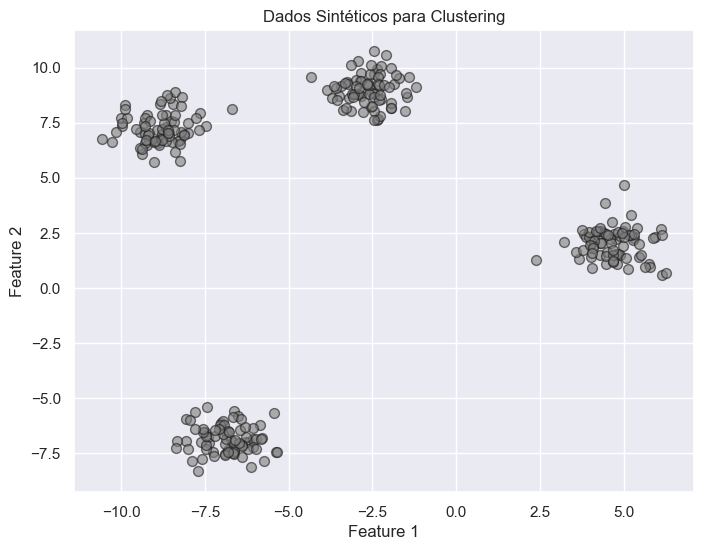

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c='gray', s=50, alpha=0.6, edgecolor='k')
plt.title("Dados Sintéticos para Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# 1. K-Means Clustering

## Aplicando o K-Means

In [5]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

c:\Users\damio\OneDrive\Documentos\Arthur\Celepar\DataCience\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não pode encontrar o arquivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\damio\OneDrive\Documentos\Arthur\Celepar\DataCience\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2

# Visualizando os clusters

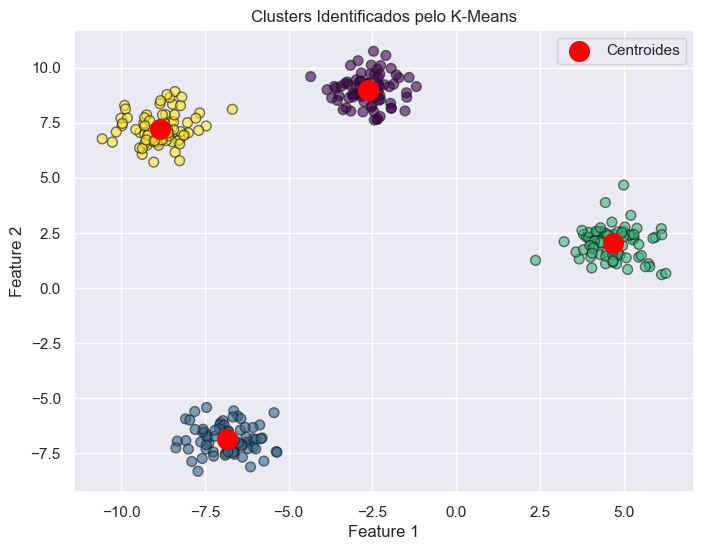

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis', alpha=0.6, edgecolor='k')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', label='Centroides')
plt.title("Clusters Identificados pelo K-Means")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

## Avaliando o modelo com silhouette_score

In [7]:
silhouette_kmeans = silhouette_score(X, y_kmeans)
print(f"Silhouette Score para K-Means: {silhouette_kmeans:.2f}")

Silhouette Score para K-Means: 0.85


# 2. Agrupamento Hierárquico (Agglomerative Clustering)

## Aplicando o Agglomerative Clustering

In [8]:
agg_clustering = AgglomerativeClustering(n_clusters=4)
y_agg = agg_clustering.fit_predict(X)


# Visualizando os clusters

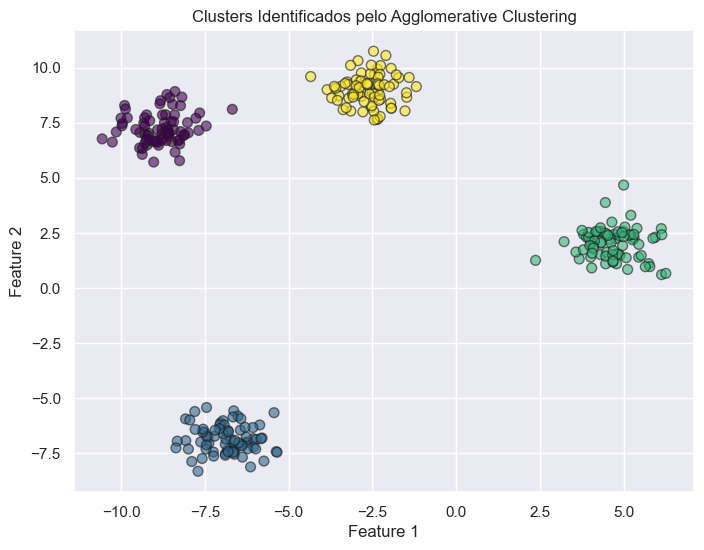

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_agg, s=50, cmap='viridis', alpha=0.6, edgecolor='k')
plt.title("Clusters Identificados pelo Agglomerative Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Avaliando o modelo com silhouette_score

In [10]:
silhouette_agg = silhouette_score(X, y_agg)
print(f"Silhouette Score para Agglomerative Clustering: {silhouette_agg:.2f}")

Silhouette Score para Agglomerative Clustering: 0.85


# Comparando os Modelos

## Tabela comparativa

In [11]:
resultados = pd.DataFrame({
    "Modelo": ["K-Means", "Agglomerative Clustering"],
    "Silhouette Score": [silhouette_kmeans, silhouette_agg]
})

In [12]:
print(resultados)

                     Modelo  Silhouette Score
0                   K-Means          0.854624
1  Agglomerative Clustering          0.854624


# Visualizando os resultados

C:\Users\damio\AppData\Local\Temp\ipykernel_37508\3019112039.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resultados, x="Modelo", y="Silhouette Score", palette="viridis")


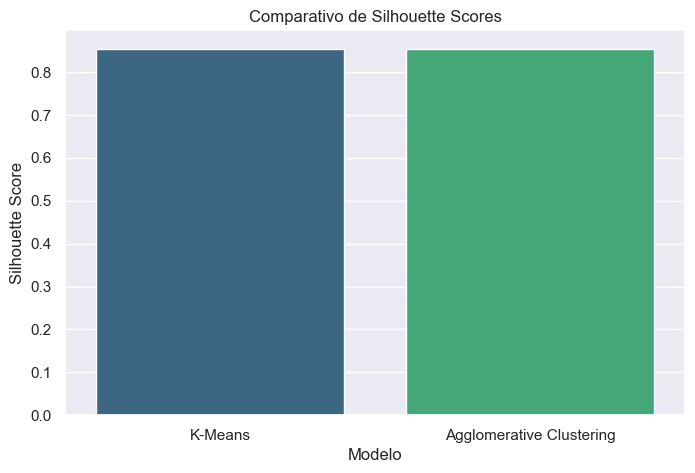

In [13]:
plt.figure(figsize=(8, 5))
sns.barplot(data=resultados, x="Modelo", y="Silhouette Score", palette="viridis")
plt.title("Comparativo de Silhouette Scores")
plt.ylabel("Silhouette Score")
plt.xlabel("Modelo")
plt.show()